<a href="https://colab.research.google.com/github/4ffan-x/Brain-Tumor-CNN/blob/main/Braintumor_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.applications import ResNet50
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import cv2
import os
from PIL import Image
from google.colab.patches import cv2_imshow
import zipfile
import matplotlib.image as mpimg
from tensorflow.keras import layers, models
import keras
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Activation, Dropout, BatchNormalization, Flatten, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import pickle

In [22]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [23]:
!kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [24]:
with zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [25]:
brain_radio = os.listdir('/content/Training/glioma')

In [26]:
brain_radio

['Tr-gl_664.jpg',
 'Tr-gl_913.jpg',
 'Tr-gl_543.jpg',
 'Tr-gl_821.jpg',
 'Tr-gl_735.jpg',
 'Tr-gl_129.jpg',
 'Tr-gl_398.jpg',
 'Tr-gl_732.jpg',
 'Tr-gl_1312.jpg',
 'Tr-gl_914.jpg',
 'Tr-gl_605.jpg',
 'Tr-gl_1002.jpg',
 'Tr-gl_15.jpg',
 'Tr-gl_320.jpg',
 'Tr-gl_876.jpg',
 'Tr-gl_1238.jpg',
 'Tr-gl_1348.jpg',
 'Tr-gl_420.jpg',
 'Tr-gl_1296.jpg',
 'Tr-gl_550.jpg',
 'Tr-gl_1083.jpg',
 'Tr-gl_463.jpg',
 'Tr-gl_1116.jpg',
 'Tr-gl_503.jpg',
 'Tr-gl_352.jpg',
 'Tr-gl_40.jpg',
 'Tr-gl_587.jpg',
 'Tr-gl_879.jpg',
 'Tr-gl_1213.jpg',
 'Tr-gl_911.jpg',
 'Tr-gl_12.jpg',
 'Tr-gl_256.jpg',
 'Tr-gl_1398.jpg',
 'Tr-gl_183.jpg',
 'Tr-gl_1367.jpg',
 'Tr-gl_1354.jpg',
 'Tr-gl_315.jpg',
 'Tr-gl_1160.jpg',
 'Tr-gl_791.jpg',
 'Tr-gl_946.jpg',
 'Tr-gl_107.jpg',
 'Tr-gl_998.jpg',
 'Tr-gl_145.jpg',
 'Tr-gl_173.jpg',
 'Tr-gl_636.jpg',
 'Tr-gl_401.jpg',
 'Tr-gl_641.jpg',
 'Tr-gl_67.jpg',
 'Tr-gl_582.jpg',
 'Tr-gl_200.jpg',
 'Tr-gl_375.jpg',
 'Tr-gl_1169.jpg',
 'Tr-gl_729.jpg',
 'Tr-gl_1287.jpg',
 'Tr-gl_481.jpg',


In [27]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [28]:
paths = []
for cls in classes:
    folder_path = "/content/Training/" + cls
    paths.append(folder_path)
    images = os.listdir(folder_path)
    print(cls, ":", len(images))

glioma : 1400
meningioma : 1400
notumor : 1400
pituitary : 1400


In [29]:
paths

['/content/Training/glioma',
 '/content/Training/meningioma',
 '/content/Training/notumor',
 '/content/Training/pituitary']

In [35]:
data = []
labels = []
for path in paths:
    label = path.split('/')[-1]

    for image_name in os.listdir(path):
        img_path = os.path.join(path, image_name)

        try:
            img = Image.open(img_path).resize((120,120)).convert('RGB')
            img = np.array(img)

            data.append(img)
            labels.append(label)

        except Exception as e:
            print(f"Error loading image: {img_path}")

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
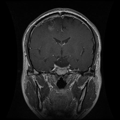

In [44]:
data[0]

In [34]:
labels[1500]

'meningioma'

In [37]:
labels[150]

'glioma'

In [38]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(labels)

one_hot_labels = to_categorical(numerical_labels)

print("Original labels (first 5):", labels[:5])
print("Numerical labels (first 5):", numerical_labels[:5])
print("One-Hot Encoded labels (first 5):\n", one_hot_labels[:5])
print("Shape of one-hot encoded labels:", one_hot_labels.shape)

Original labels (first 5): ['glioma', 'glioma', 'glioma', 'glioma', 'glioma']
Numerical labels (first 5): [0 0 0 0 0]
One-Hot Encoded labels (first 5):
 [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
Shape of one-hot encoded labels: (5600, 4)


In [41]:
one_hot_labels[2]

array([1., 0., 0., 0.])

In [45]:
X = np.array(data)
X = X / 255.0
print("Shape of image data (X):", X.shape)
print("First 5 labels (one-hot encoded):\n", one_hot_labels[:5])

Shape of image data (X): (5600, 120, 120, 3)
First 5 labels (one-hot encoded):
 [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, one_hot_labels, test_size=0.2, random_state=42, stratify=one_hot_labels)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4480, 120, 120, 3)
Shape of X_test: (1120, 120, 120, 3)
Shape of y_train: (4480, 4)
Shape of y_test: (1120, 4)


In [47]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Shape of X_train (after validation split):", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train (after validation split):", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train (after validation split): (3584, 120, 120, 3)
Shape of X_val: (896, 120, 120, 3)
Shape of y_train (after validation split): (3584, 4)
Shape of y_val: (896, 4)


In [48]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(120, 120, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(4, activation='softmax') # 4 classes for tumor types
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 118, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,862,788 (10.92 MB)

 Trainable params: 2,862,788 (10.92 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [50]:
history = model.fit(X_train, y_train, batch_size=32, epochs=25,verbose = 1, validation_data=(X_val, y_val))

Epoch 1/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6275 - loss: 0.8827 - val_accuracy: 0.7812 - val_loss: 0.5993
Epoch 2/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7916 - loss: 0.5386 - val_accuracy: 0.8292 - val_loss: 0.4483
Epoch 3/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8278 - loss: 0.4431 - val_accuracy: 0.8605 - val_loss: 0.3884
Epoch 4/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8669 - loss: 0.3560 - val_accuracy: 0.8482 - val_loss: 0.3831
Epoch 5/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8923 - loss: 0.2885 - val_accuracy: 0.8683 - val_loss: 0.3687
Epoch 6/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9090 - loss: 0.2424 - val_accuracy: 0.8761 - val_loss: 0.3654
Epoch 7/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9289 - loss: 0.1989 - val_accuracy: 0.8839 - val_loss: 0.3164
Epoch 8/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9392 - loss: 0.1600 - val_accu

In [51]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9393 - loss: 0.3108
Test Loss: 0.3107718527317047
Test Accuracy: 0.9392856955528259


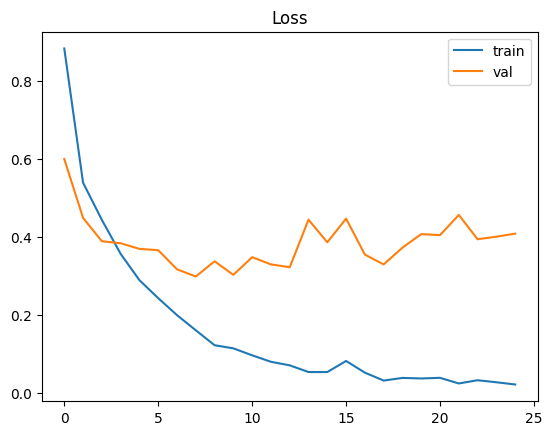

In [52]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

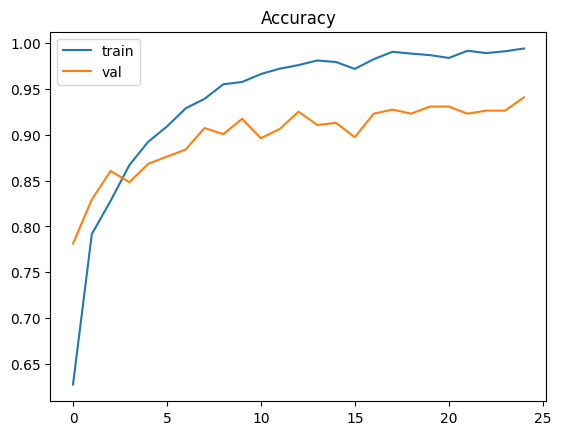

In [53]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [54]:
prediction = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


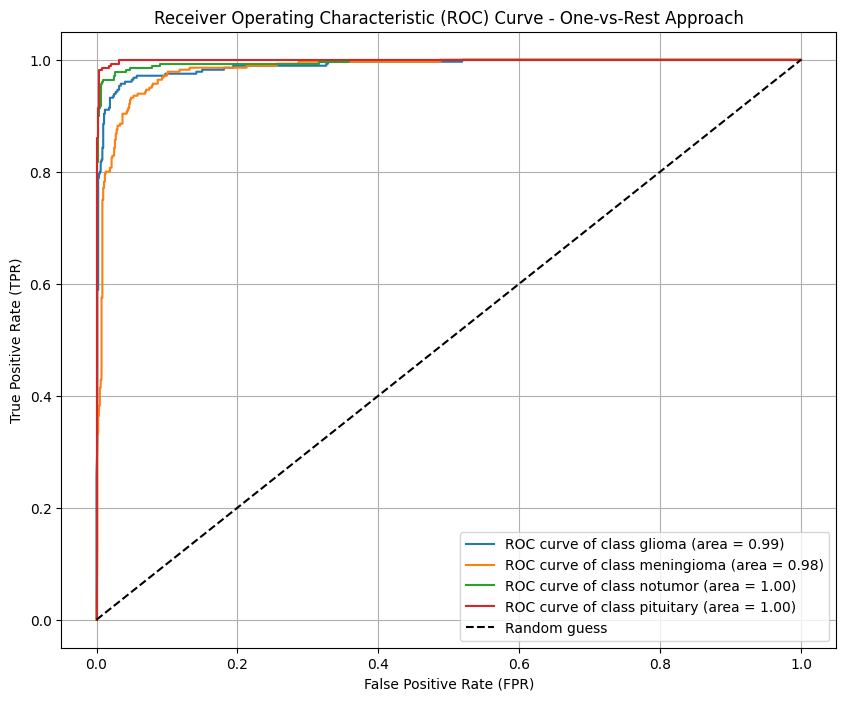


AUC scores for each class (One-vs-Rest):
  glioma: 0.99
  meningioma: 0.98
  notumor: 1.00
  pituitary: 1.00


In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = len(classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], prediction[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest Approach')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print("\nAUC scores for each class (One-vs-Rest):")
for i in range(n_classes):
    print(f"  {classes[i]}: {roc_auc[i]:.2f}")

In [55]:
y_pred = np.argmax(prediction, axis=1)
y_true = np.argmax(y_test, axis=1)

In [56]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[253,  25,   0,   2],
       [  8, 253,   7,  12],
       [  2,   5, 269,   4],
       [  0,   3,   0, 277]])

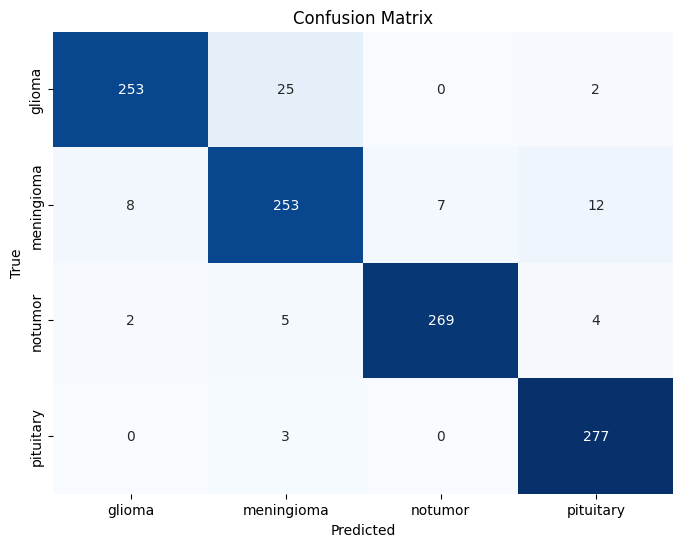

In [57]:
Confusion_Matrix = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(Confusion_Matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [58]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       280
           1       0.88      0.90      0.89       280
           2       0.97      0.96      0.97       280
           3       0.94      0.99      0.96       280

    accuracy                           0.94      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.94      0.94      1120



In [59]:
model.save('brain_tumor_classifier.keras')
print("Model saved as 'brain_tumor_classifier.keras'")

Model saved as 'brain_tumor_classifier.keras'


In [60]:
import pickle
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)
print("LabelEncoder saved as 'label_encoder.pkl'")

LabelEncoder saved as 'label_encoder.pkl'


In [ ]:
# from tensorflow import keras
# import pickle

# # Load the model
# loaded_model = keras.models.load_model('brain_tumor_classifier.keras')

# # Load the LabelEncoder
# with open('label_encoder.pkl', 'rb') as file:
#     loaded_label_encoder = pickle.load(file)

# print("Model and LabelEncoder loaded successfully.")
# # Example of using the loaded label encoder:
# # original_class_names = loaded_label_encoder.inverse_transform([0, 1, 2, 3])
# # print(original_class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


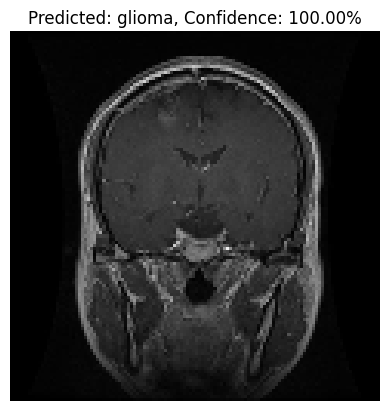

Predicted Label: glioma, Confidence Score: 100.00%


In [64]:
def detection_system(image_path, model, label_encoder, image_size=120):

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Image not found at path: {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_resized = cv2.resize(image_rgb, (image_size, image_size))

    image_normalized = image_resized / 255.0

    image_input = np.expand_dims(image_normalized, axis=0) # Re-adding this line

    predictions = model.predict(image_input)

    predicted_index = np.argmax(predictions)
    confidence_score = predictions[0][predicted_index]

    predicted_label = label_encoder.inverse_transform([predicted_index])[0]


    plt.imshow(image_resized)
    plt.title(f"Predicted: {predicted_label}, Confidence: {confidence_score*100:.2f}%")
    plt.axis('off')
    plt.show()

    return predicted_label, confidence_score

image_path = "/content/Training/glioma/Tr-gl_664.jpg"
predicted_label, confidence_score = detection_system(image_path, model, label_encoder)
print(f"Predicted Label: {predicted_label}, Confidence Score: {confidence_score*100:.2f}%")